# **SISTEMAS DE  VISION 317**
# **PRÁCTICA #5: Conteo de circulos.**
**Jose Antonio Martinez Calan 2127803**

IMPORTAR LIBRERÍAS

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

FUNCIÓN PARA MOSTRAR IMÁGENES

In [4]:
def show_image(img, title="Imagen", size=4):
    """
    Función para mostrar imágenes con Matplotlib
    """
    plt.figure(figsize=(size, size))
    if len(img.shape) == 3:
        # Convertir BGR a RGB para mostrar correctamente los colores
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

CARGAR Y VISUALIZAR LA IMAGEN ORIGINAL

 IMAGEN ORIGINAL 
 Dimensiones: (980, 980, 3)


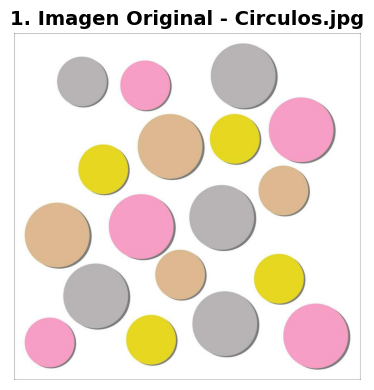

In [5]:
print(" IMAGEN ORIGINAL ")
image = cv2.imread('Circulos.jpg')
# Verificar si la imagen se cargó correctamente
if image is None:
    print("Error: No se pudo cargar 'Circulos.jpg'")
else:
    print(f" Dimensiones: {image.shape}")
# Mostrar imagen original
show_image(image, "1. Imagen Original - Circulos.jpg")

PREPROCESAMIENTO - CONVERSIÓN A GRISES Y SUAVIZADO


 PREPROCESAMIENTO 


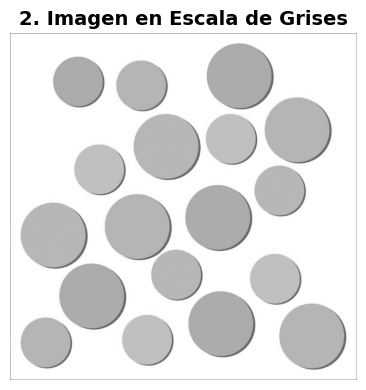

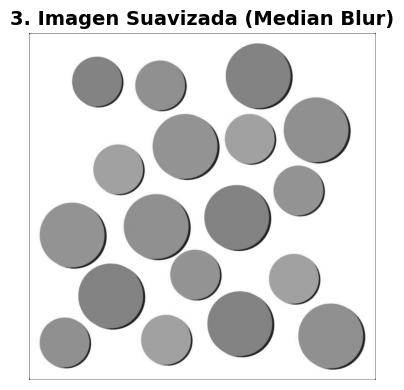

In [6]:
print("\n PREPROCESAMIENTO ")
# Convertir a escala de grises
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
show_image(gray, "2. Imagen en Escala de Grises")
# Aplicar suavizado para reducir ruido (importante para HoughCircles)
blur = cv2.medianBlur(gray, 5)
show_image(blur, "3. Imagen Suavizada (Median Blur)")

DETECCIÓN DE CÍRCULOS CON HOUGHCIRCLES

In [7]:
print("\n DETECCIÓN DE CÍRCULOS ")
# Detectar círculos usando HoughCircles
circles = cv2.HoughCircles(
    blur,                    # Imagen suavizada en escala de grises
    cv2.HOUGH_GRADIENT,      # Método de detección
    dp=1.2,                  # Razón de acumulador/resolución
    minDist=30,              # Distancia mínima entre centros de círculos
    param1=100,              # Umbral alto para el detector de bordes Canny
    param2=30,               # Umbral para la detección de centros
    minRadius=10,            # Radio mínimo de círculos a detectar
    maxRadius=80             # Radio máximo de círculos a detectar
)


 DETECCIÓN DE CÍRCULOS 


DIBUJAR Y CONTAR LOS CÍRCULOS DETECTADOS

In [8]:
print("\n CONTEO Y VISUALIZACIÓN ")
# Crear una copia de la imagen original para dibujar los resultados
output = image.copy()
if circles is not None:
    # Convertir coordenadas a enteros
    circles = np.uint16(np.around(circles))
    # Contar número de círculos detectados
    num_circulos = len(circles[0])
    print(f" Círculos detectados: {num_circulos}")
    # Dibujar cada círculo detectado
    for i, circle in enumerate(circles[0, :]):
        centro_x, centro_y, radio = circle
        # Dibujar círculo exterior (VERDE)
        cv2.circle(output, (centro_x, centro_y), radio, (0, 255, 0), 3)
        # Dibujar centro del círculo (ROJO)
        cv2.circle(output, (centro_x, centro_y), 2, (0, 0, 255), 5)
        # Opcional: Numerar los círculos
        cv2.putText(output, str(i+1), (centro_x-10, centro_y-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        print(f"   ○ Círculo {i+1}: Centro=({centro_x}, {centro_y}), Radio={radio}")
    # Agregar texto con el conteo total
    cv2.putText(output, f'Círculos detectados: {num_circulos}', (20, 40),
               cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)
else:
    print("No se detectaron círculos")
    # Segundo intento con parámetros más flexibles
    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.1,
        minDist=20,
        param1=80,
        param2=25,
        minRadius=5,
        maxRadius=100
    )
    if circles is not None:
        circles = np.uint16(np.around(circles))
        num_circulos = len(circles[0])
        print(f"✅ Círculos detectados (parámetros ajustados): {num_circulos}")
        for i, circle in enumerate(circles[0, :]):
            centro_x, centro_y, radio = circle
            cv2.circle(output, (centro_x, centro_y), radio, (0, 255, 0), 3)
            cv2.circle(output, (centro_x, centro_y), 2, (0, 0, 255), 5)
            cv2.putText(output, str(i+1), (centro_x-10, centro_y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        cv2.putText(output, f'Círculos detectados: {num_circulos}', (20, 40),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)
    else:
        print("No se detectaron círculos incluso con parámetros ajustados")
        cv2.putText(output, 'No se detectaron círculos', (20, 40),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)


 CONTEO Y VISUALIZACIÓN 
 Círculos detectados: 18
   ○ Círculo 1: Centro=(387, 866), Radio=70
   ○ Círculo 2: Centro=(191, 136), Radio=71
   ○ Círculo 3: Centro=(751, 695), Radio=71
   ○ Círculo 4: Centro=(101, 875), Radio=72
   ○ Círculo 5: Centro=(626, 299), Radio=72
   ○ Círculo 6: Centro=(761, 445), Radio=71
   ○ Círculo 7: Centro=(470, 682), Radio=71
   ○ Círculo 8: Centro=(251, 386), Radio=70
   ○ Círculo 9: Centro=(369, 147), Radio=70
   ○ Círculo 10: Centro=(602, 532), Radio=79
   ○ Círculo 11: Centro=(454, 333), Radio=79
   ○ Círculo 12: Centro=(374, 560), Radio=78
   ○ Círculo 13: Centro=(825, 285), Radio=79
   ○ Círculo 14: Centro=(137, 581), Radio=79
   ○ Círculo 15: Centro=(608, 835), Radio=79
   ○ Círculo 16: Centro=(247, 757), Radio=77
   ○ Círculo 17: Centro=(661, 134), Radio=79
   ○ Círculo 18: Centro=(868, 848), Radio=77


MOSTRAR RESULTADOS FINALES


=== RESULTADOS FINALES ===


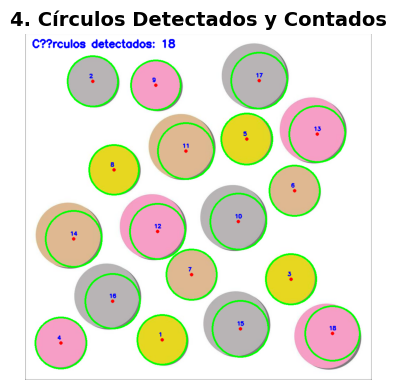

In [9]:
print("\n=== RESULTADOS FINALES ===")
show_image(output, "4. Círculos Detectados y Contados")
